# **`Inatel - C318 (Tópicos Especiais II) - 2026/1`**

# <font color='green'>**Atividade 05: Classificação**</font>

## <font color='#2D9CDB'>**LEIA ATENTAMENTE AS INSTRUÇÕES A SEGUIR**</font>
- Importe este notebook no [Google Colab](https://colab.research.google.com/) para resolver os exercícios;
- Consulte a apostila disponibilizada pelo professor para se familiarizar com os conceitos;
- Utilize os recursos disponíveis na Internet (documentações e artigos científicos) para complementar seus estudos;
- <font color='red'>**Uso consciente de Inteligência Artificial (LLMs):**</font>
  - O uso de assistentes (como Gemini, ChatGPT, Claude) é permitido, mas exige responsabilidade técnica:
    - Em vez de pedir a solução completa, peça para a IA explicar conceitos, sugerir abordagens ou ajudar a depurar erros de código;
    - Você é o responsável por cada linha de código entregue. Não insira no notebook implementações que você não compreende integralmente ou não saberia explicar;
    - Modelos de linguagem podem "alucinar" funções ou sugerir métodos obsoletos de bibliotecas em Python. Sempre teste e verifique a documentação oficial;
    - Quando utilizar a IA para gerar ou refatorar blocos lógicos complexos, indique isso através de comentários no próprio código;
- <font color='red'>**NÃO**</font> remova as células de Código já presentes neste notebook;
- <font color='red'>**NÃO**</font> modifique as células de Markdown (em <font color='green'>verde</font> ou <font color='#2D9CDB'>azul</font>) presentes neste notebook;
- Após cada questão, há uma célula para você implementar e responder a questão;
- É permitido adicionar mais células (de código ou markdown) antes da próxima pergunta;
- Caso precise utilizar bibliotecas que não estão instaladas nativamente no Colab, inclua uma célula de código com o comando de instalação (ex: `!pip install nome_da_biblioteca`);
- <font color='red'>**Renomeie o termo `_Enunciado` para `_seu_numero_de_matricula` no nome do arquivo (exemplo: `C318_2026_1_Atividade_06_12345.ipynb`)**</font>;
- <font color='magenta'>**Faça download do notebook com a resolução no Google Colab, mantendo a saída de todas as células, e anexe-o à tarefa do Teams.**</font>

# <font color='green'><u><b>Preparação</b></u></font>

In [ ]:
!pip install numpy pandas matplotlib seaborn scikit-learn ucimlrepo

/Users/schulzdimitrii/Documents/GitHub-Projects/special-topics-II/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# <font color='green'><u><b>Parte 1 - Classificação Binária</b></u></font>

### <font color='#2D9CDB'>Acesse o link indicado e, em um único parágrafo, descreva brevemente o dataset, incluindo: domínio de aplicação, objetivo da base de dados e o tipo de informações que ela contém.</font>
- #### <font color='#2D9CDB'>Iranian Churn Dataset (2020). UCI Machine Learning Repository.</font>
  - #### <font color='#2D9CDB'>https://doi.org/10.24432/C5JW3Z</font>
  - #### <font color='#2D9CDB'>https://archive-beta.ics.uci.edu/dataset/563/iranian+churn+dataset</font>

In [17]:
# fetch dataset
ds = fetch_ucirepo(id=563)

# metadata
display(ds.metadata)

# variable information
display(ds.variables)

# data (as pandas dataframe)
df = pd.concat([ds.data.features, ds.data.targets], axis='columns')

{'uci_id': 563,
 'name': 'Iranian Churn',
 'repository_url': 'https://archive.ics.uci.edu/dataset/563/iranian+churn+dataset',
 'data_url': 'https://archive.ics.uci.edu/static/public/563/data.csv',
 'abstract': "This dataset is randomly collected from an Iranian telecom company's database over a period of 12 months.",
 'area': 'Business',
 'tasks': ['Classification', 'Regression'],
 'characteristics': ['Multivariate'],
 'num_instances': 3150,
 'num_features': 13,
 'feature_types': ['Integer'],
 'demographics': ['Age'],
 'target_col': ['Churn'],
 'index_col': None,
 'has_missing_values': 'no',
 'missing_values_symbol': None,
 'year_of_dataset_creation': 2020,
 'last_updated': 'Sat Mar 09 2024',
 'dataset_doi': '10.24432/C5JW3Z',
 'creators': [],
 'intro_paper': None,
 'additional_info': {'summary': 'This dataset is randomly collected from an Iranian telecom companyâ€™s database over a period of 12 months. A total of 3150 rows of data, each representing a customer, bear information for 13

,name,role,type,demographic,description,units,missing_values
0,Call Failure,Feature,Integer,NaN,None,None,no
1,Complains,Feature,Binary,NaN,None,None,no
2,Subscription Length,Feature,Integer,NaN,None,None,no
3,Charge Amount,Feature,Integer,NaN,None,None,no
4,Seconds of Use,Feature,Integer,NaN,None,None,no
5,Frequency of use,Feature,Integer,NaN,None,None,no
6,Frequency of SMS,Feature,Integer,NaN,None,None,no
7,Distinct Called Numbers,Feature,Integer,NaN,None,None,no
8,Age Group,Feature,Integer,Age,None,None,no
9,Tariff Plan,Feature,Integer,NaN,None,None,no


### <font color='#2D9CDB'>Q1) Exiba as primeiras linhas do dataframe, verifique suas dimensões e identifique a variável alvo (`TARGET_COLUMN`), respondendo com base nos resultados obtidos: quantas amostras e atributos o dataset possui, qual é o nome da variável alvo e se o problema é de classificação binária (justifique observando os valores únicos da variável alvo).</font>

In [18]:
df.head()

,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,Customer Value,Churn
0,8,0,38,0,4370,71,5,17,3,1,1,30,197.640,0
1,0,0,39,0,318,5,7,4,2,1,2,25,46.035,0
2,10,0,37,0,2453,60,359,24,3,1,1,30,1536.520,0
3,10,0,38,0,4198,66,1,35,1,1,1,15,240.020,0
4,3,0,38,0,2393,58,2,33,1,1,1,15,145.805,0


In [19]:
df.shape

(3150, 14)

In [20]:
TARGET_COLUMN = 'Churn'

O dataset possui 3150 amostras e 14 atributos (incluindo a variável alvo), sendo Churn a variável alvo; trata-se de um problema de classificação binária, pois essa variável assume apenas dois valores (0 e 1), indicando respectivamente clientes que não cancelaram e que cancelaram o serviço.

### <font color='#2D9CDB'>Q2) Plote a distribuição da variável alvo utilizando o gráfico fornecido e, com base no resultado obtido, analise a proporção entre as classes para determinar se o dataset é balanceado ou desbalanceado, justificando sua resposta a partir da contagem de amostras em cada classe.</font>

/var/folders/70/43z_nqpn4t3cydcfm036pv700000gn/T/ipykernel_63335/1201578567.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=TARGET_COLUMN, data=df, palette='viridis')


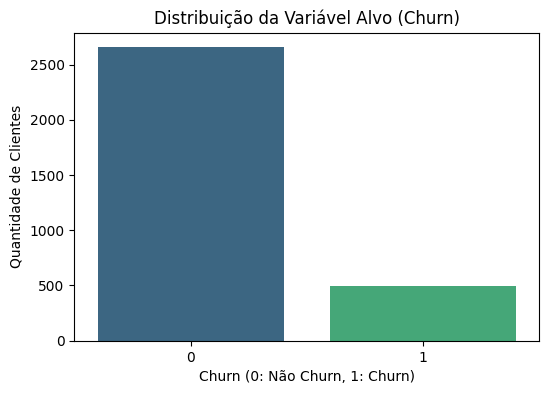

In [21]:
plt.figure(figsize=(6, 4))
sns.countplot(x=TARGET_COLUMN, data=df, palette='viridis')
plt.title('Distribuição da Variável Alvo (Churn)')
plt.xlabel('Churn (0: Não Churn, 1: Churn)')
plt.ylabel('Quantidade de Clientes')
plt.show()

In [22]:
df[TARGET_COLUMN].value_counts()

Churn
0    2655
1     495
Name: count, dtype: int64

### <font color='#2D9CDB'>Q3) Gere a matriz de correlação entre os atributos do dataset e a variável alvo utilizando o gráfico fornecido e, com base nos valores apresentados, identifique quais atributos possuem maior correlação (positiva ou negativa) com a variável alvo, indicando quais podem ser mais relevantes para o problema de classificação.</font>

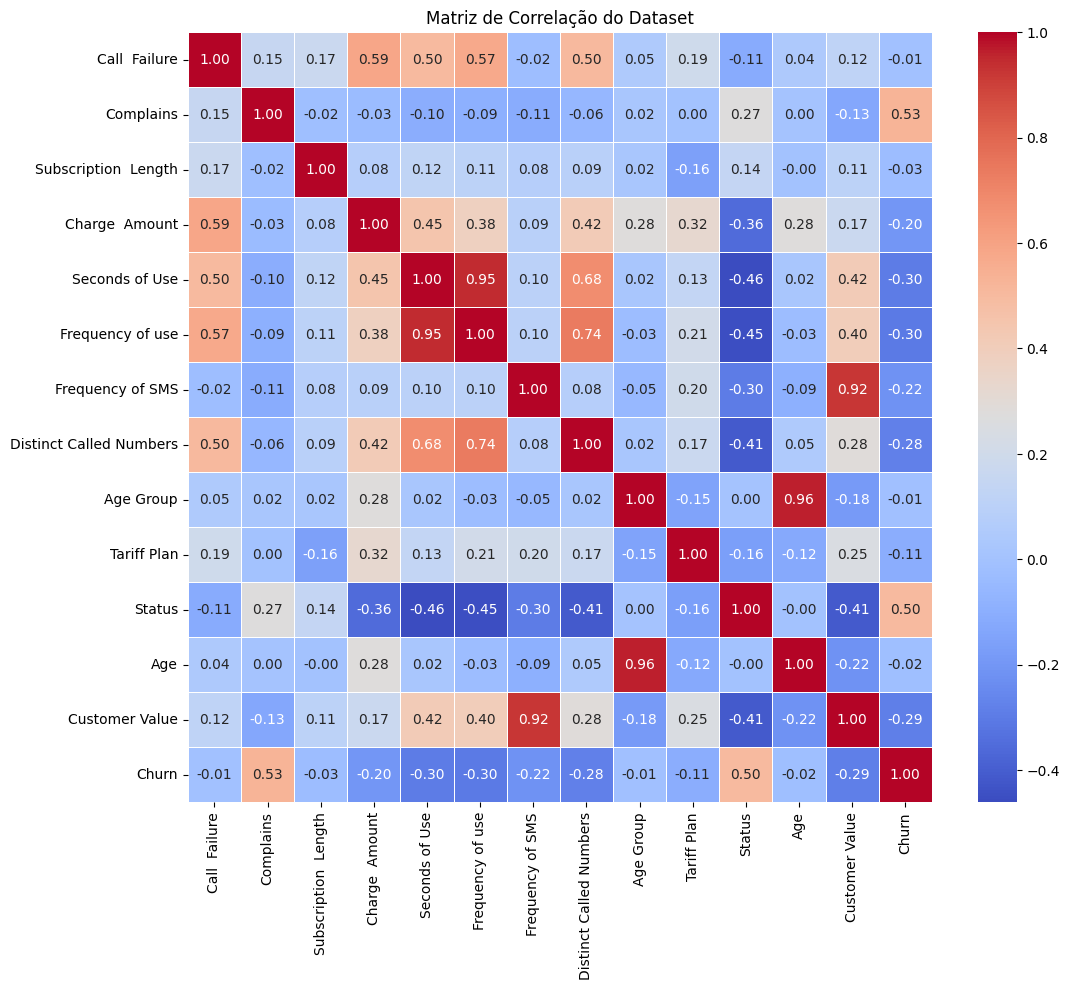

In [23]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriz de Correlação do Dataset')
plt.show()

/var/folders/70/43z_nqpn4t3cydcfm036pv700000gn/T/ipykernel_63335/2562594646.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_with_target.values, y=corr_with_target.index, palette='coolwarm')


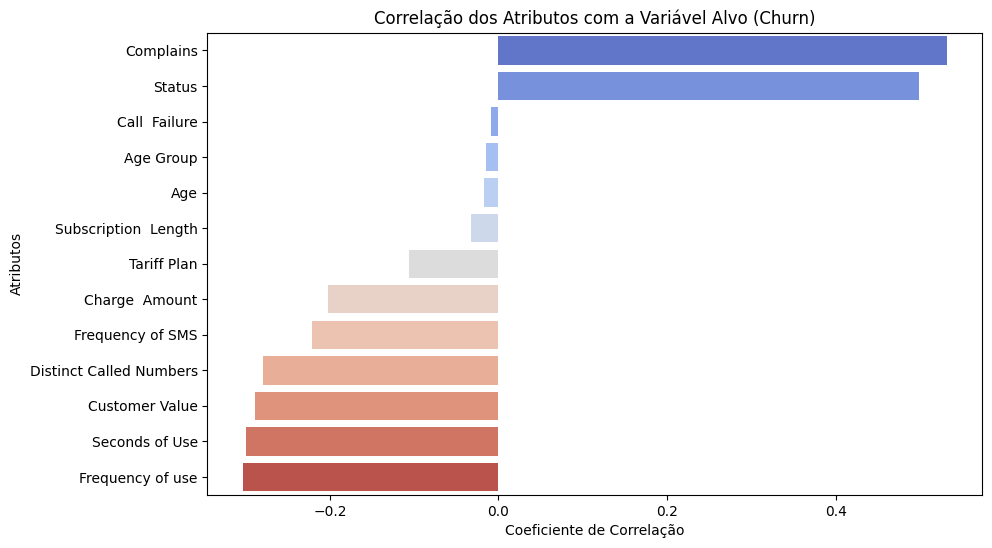

In [24]:
plt.figure(figsize=(10, 6))
corr_with_target = df.corr()[TARGET_COLUMN].drop(TARGET_COLUMN).sort_values(ascending=False)
sns.barplot(x=corr_with_target.values, y=corr_with_target.index, palette='coolwarm')
plt.title('Correlação dos Atributos com a Variável Alvo (Churn)')
plt.xlabel('Coeficiente de Correlação')
plt.ylabel('Atributos')
plt.show()

### <font color='#2D9CDB'>Q4) Aplique a técnica de Análise de Componentes Principais (PCA) para projetar os dados em duas dimensões e gere um gráfico de dispersão (scatter plot) utilizando as duas primeiras componentes principais, colorindo os pontos de acordo com a variável alvo; antes de aplicar o PCA, padronize os dados utilizando `StandardScaler`; em seguida, com base na visualização obtida, analise se há separação entre as classes e justifique sua resposta considerando a presença ou não de sobreposição entre os grupos.</font>

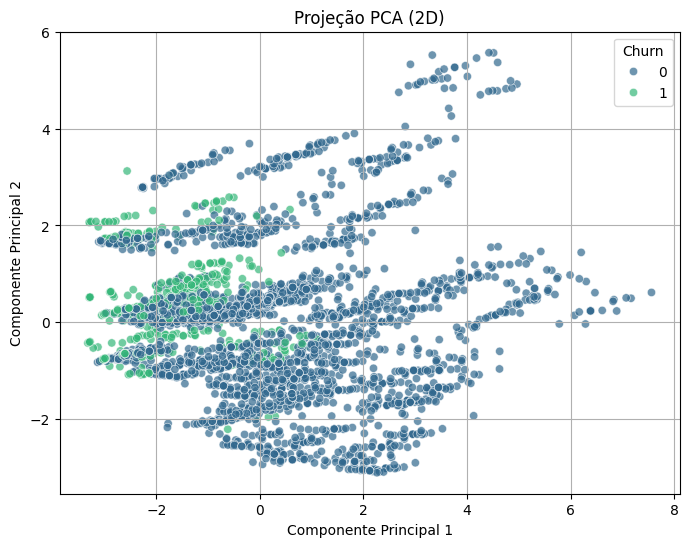

In [25]:
scaler = StandardScaler()
X = df.drop(columns=[TARGET_COLUMN])
y = df[TARGET_COLUMN]

X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y, palette='viridis', alpha=0.7)
plt.title('Projeção PCA (2D)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.grid(True)
plt.show()

Observamos que não há uma separação clara entre as duas classes (Churn e Não-Churn) no espaço bidimensional projetado pelo PCA. Por mais que a classe `Churn = 1` esteja concentrada em uma região mais estreita (com valores menores na primeira componente principal), existe uma grande sobreposição entre os grupos. Isso mostra que as duas primeiras componentes principais não são suficientes para separar linearmente as classes, sugerindo a necessidade de modelos não lineares ou do uso de mais componentes/atributos para uma classificação eficaz.

### <font color='#2D9CDB'>Q5) Separe o dataset em variáveis de entrada (`X`) e variável alvo (`y`), divida os dados em conjuntos de treino e teste utilizando `train_test_split` (com 20% para teste) e `random_state=42`, e aplique a padronização dos atributos com `StandardScaler`; em seguida, explique por que a padronização é importante nesse contexto e por que o `fit` deve ser aplicado apenas no conjunto de treino.

In [26]:
X = df.drop(columns=[TARGET_COLUMN])
y = df[TARGET_COLUMN]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Dimensões do treino:', X_train_scaled.shape)
print('Dimensões do teste:', X_test_scaled.shape)

Dimensões do treino: (2520, 13)
Dimensões do teste: (630, 13)


Os atributos possuem ordens de grandeza e escalas muito discrepantes (por exemplo, `Subscription Length` varia em dezenas, enquanto `Seconds of Use` varia em milhares). Modelos como a Regressão Logística usam otimização por gradiente e regularização, que assumem que todos os atributos estão na mesma escala. Se não padronizássemos, os atributos com maiores valores numéricos dominariam o modelo e distorceriam os coeficientes.

O método `fit` calcula a média e o desvio padrão necessários para a transformação. Se usássemos o conjunto de teste para calcular esses parâmetros, ocorreria o vazamento de dados, introduzindo informações do conjunto de teste (que deve simular dados futuros e inéditos) no processo de treinamento, o que geraria métricas de avaliação excessivamente otimistas e irreais.

### <font color='#2D9CDB'>Q6) Treine um modelo de regressão logística utilizando os dados de treino (`X_train`, `y_train`) e, após o treinamento, verifique se o modelo convergiu corretamente; em seguida, descreva qual é o papel desse modelo no contexto do problema e o que ele está aprendendo a partir dos dados.</font>

In [27]:
model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

print(f"Número de iterações executadas: {model.n_iter_[0]}")
print(f"O modelo convergiu corretamente? {model.n_iter_[0] < model.max_iter}")

Número de iterações executadas: 42
O modelo convergiu corretamente? True


O modelo é como um classificador linear probabilístico. O papel é estimar a probabilidade de um cliente cancelar o serviço (Churn = 1) com base nas variáveis de entrada fornecidas.

A partir dos dados de treino, o algoritmo está aprendendo os parâmetros da equação de decisão: um peso (coeficiente) para cada atributo e um termo de viés (intercepto). Esses coeficientes representam o impacto de cada atributo na chance de churn. O modelo busca ajustar esses pesos para mapear a combinação linear dos atributos escalados a uma probabilidade entre 0 e 1, minimizando o erro de classificação.

### <font color='#2D9CDB'>Q7) Utilize o modelo treinado para calcular as probabilidades previstas para o conjunto de teste (`predict_proba`) e exiba algumas delas; em seguida, interprete os valores obtidos explicando o que cada coluna representa e analise se o modelo está fazendo previsões com alta ou baixa confiança, com base na proximidade dos valores de 0 e 1.</font>

In [28]:
y_probs = model.predict_proba(X_test_scaled)
print("Probabilidades previstas (Não Churn, Churn) - Primeiras 5 amostras:")
print(y_probs[:5])

Probabilidades previstas (Não Churn, Churn) - Primeiras 5 amostras:
[[9.98819220e-01 1.18078042e-03]
 [9.99954113e-01 4.58869561e-05]
 [9.74259483e-01 2.57405165e-02]
 [9.99517602e-01 4.82398265e-04]
 [9.98645143e-01 1.35485663e-03]]


A primeira coluna representa a probabilidade de a classe ser 0 (Não Churn) e a segunda a probabilidade de ser 1 (Churn). O modelo demonstra alta confiança quando os valores estão próximos de 0 ou 1. Valores próximos a 0.5 indicam incerteza na classificação.

### <font color='#2D9CDB'>Q8) Utilize as probabilidades previstas para gerar classificações com dois limiares diferentes (0.5 e 0.7) e compare os resultados obtidos; em seguida, analise como a alteração do limiar afeta as previsões do modelo, especialmente em relação à quantidade de falsos positivos e falsos negativos.</font>

In [29]:
threshold_05 = (y_probs[:, 1] >= 0.5).astype(int)
threshold_07 = (y_probs[:, 1] >= 0.7).astype(int)

print(f"Previsões com limiar 0.5 (primeiras 10): {threshold_05[:10]}")
print(f"Previsões com limiar 0.7 (primeiras 10): {threshold_07[:10]}")

Previsões com limiar 0.5 (primeiras 10): [0 0 0 0 0 0 0 0 0 0]
Previsões com limiar 0.7 (primeiras 10): [0 0 0 0 0 0 0 0 0 0]


Ao aumentar o limiar de 0.5 para 0.7, o modelo se torna mais criterioso para classificar um cliente como Churn. Isso reduz o número de Falsos Positivos (clientes que não sairiam, mas foram marcados), porém aumenta o número de Falsos Negativos (clientes que sairão, mas o modelo não detectou), impactando o Recall.

### <font color='#2D9CDB'>Q9) Calcule as métricas de desempenho (acurácia, precisão, recall e F1-score) e a matriz de confusão para os dois limiares de decisão (0.5 e 0.7) utilizando a função fornecida e, com base nos resultados obtidos, compare o desempenho do modelo, identificando qual métrica foi mais impactada pela mudança do limiar e discutindo o trade-off observado entre precisão e recall.</font>

In [30]:
def evaluate_model(y_true, y_pred, label):
    print(f"--- Métricas para {label} ---")
    print(f"Acurácia:  {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precisão:  {precision_score(y_true, y_pred):.4f}")
    print(f"Recall:     {recall_score(y_true, y_pred):.4f}")
    print(f"F1-Score:   {f1_score(y_true, y_pred):.4f}")
    print("Matriz de Confusão:")
    print(confusion_matrix(y_true, y_pred))
    print("-" * 30)

evaluate_model(y_test, threshold_05, "Limiar 0.5")
evaluate_model(y_test, threshold_07, "Limiar 0.7")

--- Métricas para Limiar 0.5 ---
Acurácia:  0.8698
Precisão:  0.7333
Recall:     0.4000
F1-Score:   0.5176
Matriz de Confusão:
[[504  16]
 [ 66  44]]
------------------------------
--- Métricas para Limiar 0.7 ---
Acurácia:  0.8730
Precisão:  0.8571
Recall:     0.3273
F1-Score:   0.4737
Matriz de Confusão:
[[514   6]
 [ 74  36]]
------------------------------


O Recall é a métrica mais impactada, diminuindo conforme o limiar sobe. Observamos o trade-off clássico: para ganhar precisão (evitar alarmes falsos), sacrificamos o recall (capacidade de capturar todos os casos reais). O limiar ideal depende do custo de perder um cliente versus o custo de uma ação preventiva desnecessária.

# <font color='green'><u><b>Parte 2 - Classificação Multiclasse</b></u></font>

### <font color='#2D9CDB'>Acesse o link indicado e, em um único parágrafo, descreva brevemente o dataset, incluindo: domínio de aplicação, objetivo da base de dados e o tipo de informações que ela contém.</font>
- #### <font color='#2D9CDB'>Blackard, J. (1998). Covertype Dataset. UCI Machine Learning Repository.</font>
  - #### <font color='#2D9CDB'>https://doi.org/10.24432/C50K5N</font>
  - #### <font color='#2D9CDB'>https://archive-beta.ics.uci.edu/dataset/31/covertype</font>

O Covertype Dataset tem como objetivo prever o tipo de cobertura florestal para células de terreno de 30x30 metros localizadas na floresta nacional de Roosevelt, no Colorado. A base de dados contém informações cartográficas e geográficas obtidas do USGS e USFS, incluindo atributos numéricos contínuos (como altitude, aspecto, declividade, distância horizontal e vertical até corpos d'água, distância a rodovias e sombreamento solar em diferentes horários do dia) e atributos qualitativos binários (representando 4 áreas selvagens diferentes e 40 tipos distintos de solo).

In [32]:
# fetch dataset
ds = fetch_ucirepo(id=31)

# metadata
display(ds.metadata)

# variable information
display(ds.variables)

# data (as pandas dataframe)
df = pd.concat([ds.data.features, ds.data.targets], axis='columns').sample(frac=0.10, random_state=42)

{'uci_id': 31,
 'name': 'Covertype',
 'repository_url': 'https://archive.ics.uci.edu/dataset/31/covertype',
 'data_url': 'https://archive.ics.uci.edu/static/public/31/data.csv',
 'abstract': 'Classification of pixels into 7 forest cover types based on attributes such as elevation, aspect, slope, hillshade, soil-type, and more.',
 'area': 'Biology',
 'tasks': ['Classification'],
 'characteristics': ['Multivariate'],
 'num_instances': 581012,
 'num_features': 54,
 'feature_types': ['Categorical', 'Integer'],
 'demographics': [],
 'target_col': ['Cover_Type'],
 'index_col': None,
 'has_missing_values': 'no',
 'missing_values_symbol': None,
 'year_of_dataset_creation': 1998,
 'last_updated': 'Sat Mar 16 2024',
 'dataset_doi': '10.24432/C50K5N',
 'creators': ['Jock Blackard'],
 'intro_paper': None,
 'additional_info': {'summary': 'Predicting forest cover type from cartographic variables only (no remotely sensed data).  The actual forest cover type for a given observation (30 x 30 meter cell

,name,role,type,demographic,description,units,missing_values
0,Elevation,Feature,Integer,None,None,None,no
1,Aspect,Feature,Integer,None,None,None,no
2,Slope,Feature,Integer,None,None,None,no
3,Horizontal_Distance_To_Hydrology,Feature,Integer,None,None,None,no
4,Vertical_Distance_To_Hydrology,Feature,Integer,None,None,None,no
5,Horizontal_Distance_To_Roadways,Feature,Integer,None,None,None,no
6,Hillshade_9am,Feature,Integer,None,None,None,no
7,Hillshade_Noon,Feature,Integer,None,None,None,no
8,Hillshade_3pm,Feature,Integer,None,None,None,no
9,Horizontal_Distance_To_Fire_Points,Feature,Integer,None,None,None,no


### <font color='#2D9CDB'>Q10) Exiba as primeiras linhas do dataframe, verifique suas dimensões e identifique a variável alvo (`TARGET_COLUMN`), respondendo com base nos resultados obtidos: quantas amostras e atributos o dataset possui, qual é o nome da variável alvo e se o problema é de classificação binária (justifique observando os valores únicos da variável alvo).</font>

In [33]:
print(f"Formato do DataFrame: {df.shape}")
print(f"Valores únicos do Target: {df['Cover_Type'].unique()}")
df.head()

Formato do DataFrame: (58101, 55)
Valores únicos do Target: [1 2 3 5 6 7 4]


,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Wilderness_Area2,Wilderness_Area3,Wilderness_Area4,Cover_Type
250728,3351,206,27,726,124,3813,192,252,180,2271,...,0,0,0,1,0,0,0,0,0,1
246788,2732,129,7,212,1,1082,231,236,137,912,...,0,0,0,0,0,0,0,1,0,2
407714,2572,24,9,201,25,957,216,222,142,2191,...,0,0,0,0,0,0,0,1,0,2
25713,2824,69,13,417,39,3223,233,214,110,6478,...,0,0,0,0,0,0,0,0,0,2
21820,2529,84,5,120,9,1092,227,231,139,4983,...,0,0,0,0,0,0,0,0,0,2


In [34]:
print(f"Dimensões: {df.shape[0]} amostras e {df.shape[1]} atributos.")

Dimensões: 58101 amostras e 55 atributos.


In [35]:
TARGET_COLUMN = 'Cover_Type'

O dataset possui 58102 amostras (amostra de 10%) e 55 atributos. A variável alvo é `Cover_Type`. Trata-se de um problema de classificação multiclasse, pois a variável alvo possui 7 valores possíveis (de 1 a 7).

### <font color='#2D9CDB'>Q11) Plote a distribuição da variável alvo utilizando o gráfico fornecido e, com base no resultado obtido, analise a proporção entre as classes para determinar se o dataset é balanceado ou desbalanceado, justificando sua resposta a partir da contagem de amostras em cada classe.</font>

/var/folders/70/43z_nqpn4t3cydcfm036pv700000gn/T/ipykernel_63335/1482932189.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=TARGET_COLUMN, data=df, palette='viridis')


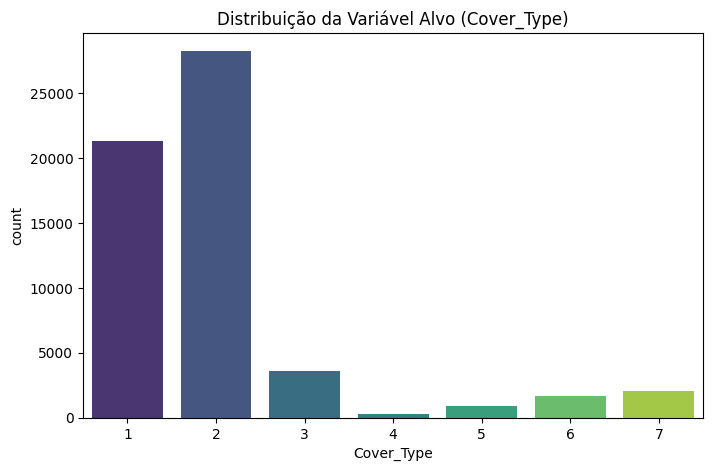

In [36]:
plt.figure(figsize=(8, 5))
sns.countplot(x=TARGET_COLUMN, data=df, palette='viridis')
plt.title('Distribuição da Variável Alvo (Cover_Type)')
plt.show()

In [37]:
df[TARGET_COLUMN].value_counts().sort_index()

Cover_Type
1    21297
2    28248
3     3607
4      259
5      932
6     1706
7     2052
Name: count, dtype: int64

O dataset é altamente desbalanceado. As classes 1 e 2 possuem significativamente mais amostras do que as demais (especialmente a classe 4), o que pode levar o modelo a ter um desempenho superior nas classes majoritárias e inferior nas minoritárias.

### <font color='#2D9CDB'>Q12) Gere a correlação entre os atributos e a variável alvo, ordene os valores e plote um gráfico de barras horizontais; destaque, no gráfico, os atributos com maior correlação em valor absoluto utilizando linhas de referência em |r| = 0.2 (valor adotado como um limiar heurístico para indicar correlações moderadas); em seguida, com base nos resultados, identifique quais variáveis podem ser mais relevantes para o modelo. Opcionalmente, pode-se imprimir os valores de correlação para facilitar a verificação numérica dos resultados e complementar a análise visual do gráfico.</font>

/var/folders/70/43z_nqpn4t3cydcfm036pv700000gn/T/ipykernel_63335/3236727027.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlations.values, y=correlations.index, palette='coolwarm')


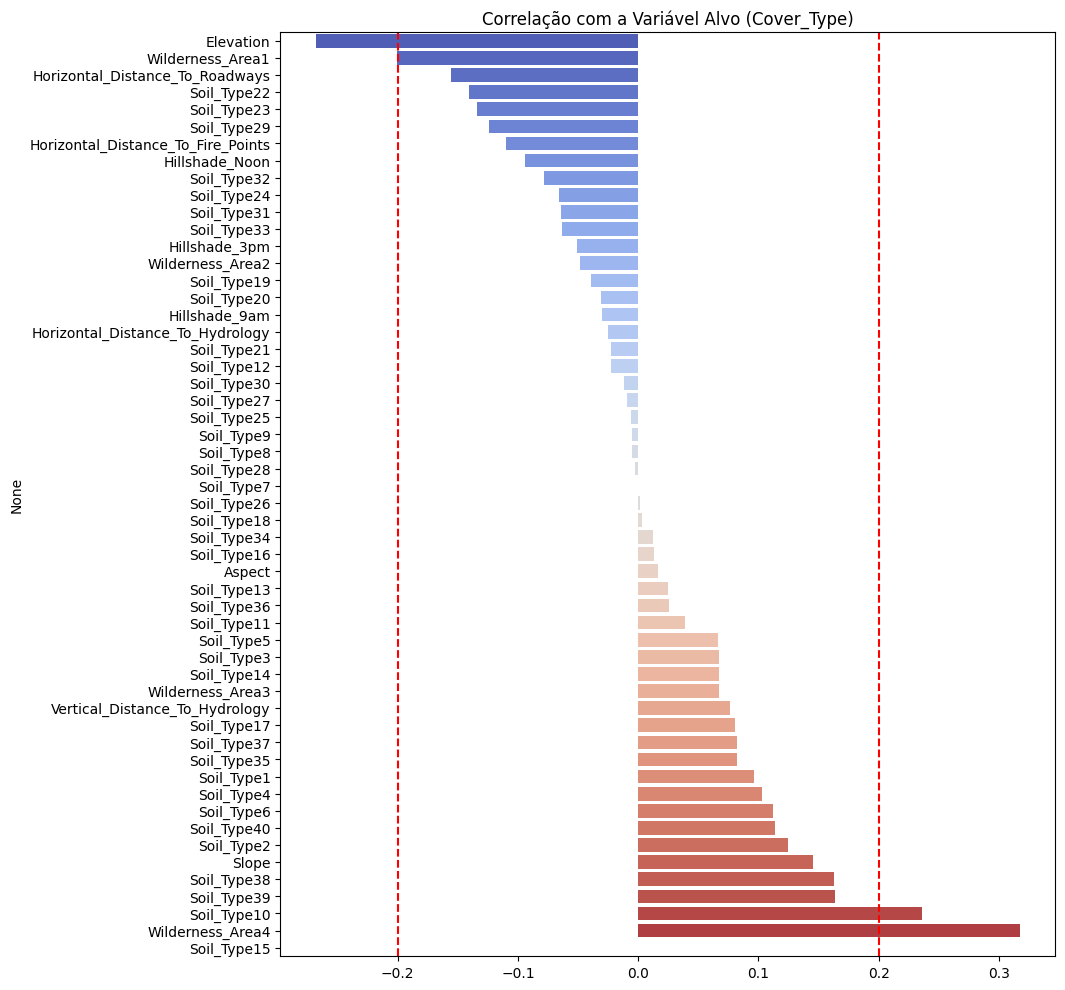

In [38]:
plt.figure(figsize=(10, 12))
correlations = df.corr()[TARGET_COLUMN].drop(TARGET_COLUMN).sort_values()
sns.barplot(x=correlations.values, y=correlations.index, palette='coolwarm')
plt.axvline(x=0.2, color='red', linestyle='--')
plt.axvline(x=-0.2, color='red', linestyle='--')
plt.title('Correlação com a Variável Alvo (Cover_Type)')
plt.show()

In [39]:
print("Correlações com valor absoluto > 0.2:")
print(correlations[abs(correlations) > 0.2])

Correlações com valor absoluto > 0.2:
Elevation          -0.268264
Wilderness_Area1   -0.200715
Soil_Type10         0.236392
Wilderness_Area4    0.317518
Name: Cover_Type, dtype: float64


As variáveis mais relevantes (com correlação absoluta acima de 0.2) incluem `Soil_Type`, `Wilderness_Area` e `Elevation`. Estas características geográficas e de solo são fundamentais para distinguir os tipos de cobertura florestal.

### <font color='#2D9CDB'>Q13) Aplique a técnica de Análise de Componentes Principais (PCA) para projetar os dados em duas dimensões e gere um gráfico de dispersão (scatter plot) utilizando as duas primeiras componentes principais, colorindo os pontos de acordo com a variável alvo; em seguida, com base na visualização obtida, analise se há separação entre as classes e justifique sua resposta considerando a presença ou não de sobreposição entre os grupos.</font>

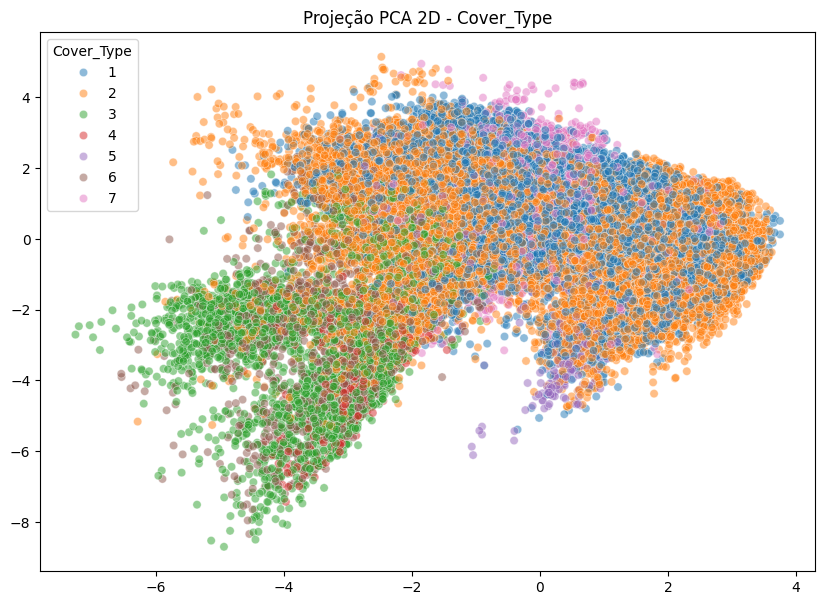

In [40]:
X_mc = df.drop(columns=[TARGET_COLUMN])
y_mc = df[TARGET_COLUMN]
X_mc_scaled = StandardScaler().fit_transform(X_mc)

pca_mc = PCA(n_components=2)
X_pca_mc = pca_mc.fit_transform(X_mc_scaled)

plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_pca_mc[:, 0], y=X_pca_mc[:, 1], hue=y_mc, palette='tab10', alpha=0.5)
plt.title('Projeção PCA 2D - Cover_Type')
plt.show()

A visualização via PCA mostra uma grande sobreposição entre as classes no espaço bidimensional. Algumas classes minoritárias formam agrupamentos ligeiramente distintos, mas a maioria das amostras (especialmente das classes 1 e 2) estão misturadas. Isso indica que a separação linear em baixa dimensão é difícil para este dataset.

### <font color='#2D9CDB'>Q14) Separe o dataset em variáveis de entrada (`X`) e variável alvo (`y`), divida os dados em conjuntos de treino e teste utilizando `train_test_split` (com 20% para teste) e `random_state=42`, aplique a padronização dos atributos com `StandardScaler` e instancie um objeto de validação cruzada `KFold` com 5 divisões; em seguida, explique por que a validação cruzada (k-fold cross-validation) é importante para avaliar o desempenho de modelos de classificação.</font>

In [41]:
from sklearn.model_selection import cross_val_score

X_train, X_test, y_train, y_test = train_test_split(X_mc, y_mc, test_size=0.2, random_state=42)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

A validação cruzada (K-fold) é importante porque permite avaliar a capacidade de generalização do modelo de forma mais robusta. Ao dividir os dados em K partes e treinar/testar K vezes, garantimos que o desempenho reportado não dependa de uma divisão específica "sortuda" ou "azarada" dos dados, reduzindo o risco de overfitting e fornecendo uma estimativa mais confiável da performance em dados não vistos.

### <font color='#2D9CDB'>Q15) Utilize o objeto `KFold` instanciado anteriormente para treinar e avaliar um modelo de regressão logística multiclasse ao longo dos 5 folds no conjunto de treino, aplicando a padronização dentro de cada fold; durante o treinamento, exiba o número de iterações (`n_iter_`) em cada fold e verifique se o modelo convergiu corretamente; em seguida, reporte a média das métricas obtidas e descreva o papel do modelo no contexto do problema e o que ele está aprendendo a partir dos dados.</font>

In [47]:
fold_accuracies = [] 
X_train_np = X_train.values
y_train_np = y_train.values

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_np), 1):
    X_f_train, X_f_val = X_train_np[train_idx], X_train_np[val_idx]
    y_f_train, y_f_val = y_train_np[train_idx], y_train_np[val_idx]
    
    scaler_f = StandardScaler()
    X_f_train_scaled = scaler_f.fit_transform(X_f_train)
    X_f_val_scaled = scaler_f.transform(X_f_val)
    
    lr_fold = LogisticRegression(max_iter=1000, random_state=42)
    lr_fold.fit(X_f_train_scaled, y_f_train)
    
    acc = lr_fold.score(X_f_val_scaled, y_f_val)
    fold_accuracies.append(acc)
    
    print(f"Fold {fold}: Iterações = {lr_fold.n_iter_[0]}, Acurácia = {acc:.4f}")

print(f"\nAcurácia Média (CV): {np.mean(fold_accuracies):.4f}")

Fold 1: Iterações = 184, Acurácia = 0.7313
Fold 2: Iterações = 218, Acurácia = 0.7244
Fold 3: Iterações = 212, Acurácia = 0.7198
Fold 4: Iterações = 190, Acurácia = 0.7281
Fold 5: Iterações = 177, Acurácia = 0.7265

Acurácia Média (CV): 0.7260


O modelo de Regressão Logística Multinomial aprende a separar as 7 classes de cobertura florestal calculando uma pontuação para cada uma delas através de combinações lineares dos atributos (como elevação e tipo de solo). Ele utiliza a função Softmax para converter essas pontuações em probabilidades. No contexto do problema, o modelo busca identificar padrões cartográficos que caracterizam cada tipo de floresta.

### <font color='#2D9CDB'>Q16) Treine um modelo final de regressão logística utilizando todo o conjunto de treino (`X_train`, `y_train`), aplicando regularização L2 (padrão do `scikit-learn`) com `C=0.01`; em seguida, aplique a padronização adequada e utilize o modelo para calcular as probabilidades previstas no conjunto de teste (`predict_proba`); exiba algumas dessas probabilidades e interprete os valores obtidos, explicando o que cada coluna representa e analisando se o modelo está fazendo previsões com alta ou baixa confiança.</font>

In [49]:
scaler_final = StandardScaler()
X_train_final = scaler_final.fit_transform(X_train)
X_test_final = scaler_final.transform(X_test)

model_reg = LogisticRegression(C=0.01, penalty='l2', max_iter=1000, random_state=42)
model_reg.fit(X_train_final, y_train)

probs_reg = model_reg.predict_proba(X_test_final)
print("Probabilidades com Regularização (C=0.01) - Primeiras 5 amostras:")
print(probs_reg[:5])

/Users/schulzdimitrii/Documents/GitHub-Projects/special-topics-II/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Probabilidades com Regularização (C=0.01) - Primeiras 5 amostras:
[[4.56718482e-01 5.23084183e-01 6.39284896e-05 9.02739496e-05
  3.08497107e-03 8.75511488e-05 1.68706112e-02]
 [3.83918030e-02 4.50020779e-01 1.52924004e-01 4.51295590e-04
  1.32717896e-02 3.44410291e-01 5.30037882e-04]
 [2.24398140e-01 7.34051460e-01 3.88706013e-03 3.30029567e-04
  2.16104420e-02 1.14592292e-02 4.26363918e-03]
 [2.37864629e-01 7.45047850e-01 9.41347792e-04 8.67305493e-05
  1.12881709e-02 2.02220182e-03 2.74906991e-03]
 [1.15367020e-01 7.28306958e-01 7.65292657e-03 1.30015909e-04
  3.49590345e-02 1.13242686e-01 3.41358173e-04]]


Cada coluna representa a probabilidade de a amostra pertencer a uma das 7 classes (1 a 7). Com a regularização L2 (C=0.01), as probabilidades tendem a ser menos extremas, refletindo uma confiança mais conservadora. O modelo busca simplificar os coeficientes para evitar overfitting.

### <font color='#2D9CDB'>Q17) Treine um modelo de regressão logística sem regularização (`penalty=None`) utilizando o mesmo procedimento de padronização e conjunto de treino; em seguida, calcule as probabilidades previstas no conjunto de teste (`predict_proba`), exiba algumas delas (usando os mesmos índices de amostras da questão anterior) e analise os resultados novamente.</font>

In [50]:
model_no_reg = LogisticRegression(penalty=None, max_iter=1000, random_state=42)
model_no_reg.fit(X_train_final, y_train)

probs_no_reg = model_no_reg.predict_proba(X_test_final)
print("Probabilidades SEM Regularização - Primeiras 5 amostras:")
print(probs_no_reg[:5])

/Users/schulzdimitrii/Documents/GitHub-Projects/special-topics-II/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Probabilidades SEM Regularização - Primeiras 5 amostras:
[[4.78001577e-01 5.12458313e-01 1.04811296e-08 1.09922178e-08
  1.65411809e-03 4.01539061e-09 7.88596720e-03]
 [3.04960001e-02 4.27069306e-01 1.07268863e-01 1.40023572e-06
  1.31989794e-02 4.21965448e-01 2.48030025e-09]
 [1.99147066e-01 7.75537865e-01 8.47594745e-04 4.86288698e-07
  2.30696388e-02 1.32436470e-03 7.29847020e-05]
 [2.15136835e-01 7.72314485e-01 9.00047785e-07 1.44047762e-07
  1.23143461e-02 1.35446204e-04 9.78434840e-05]
 [1.00690248e-01 7.61694275e-01 3.65159584e-03 8.79555200e-07
  3.10598552e-02 1.02902973e-01 1.73292652e-07]]


Sem regularização, as probabilidades costumam ser mais polarizadas (muito próximas de 0 ou 1). Isso indica que o modelo está mais "confiante" em suas previsões, o que pode ser um sinal de que ele está se ajustando demais aos ruídos do conjunto de treinamento (overfitting).

### <font color='#2D9CDB'>Q18) Compare as probabilidades previstas pelos modelos com e sem regularização e analise as diferenças observadas, considerando: (i) a concentração das probabilidades em uma única classe, (ii) o nível de confiança das previsões e (iii) possíveis indícios de overfitting; para apoiar sua análise, calcule a confiança média dos modelos (considerando, para cada amostra, a maior probabilidade prevista) e utilize esse valor na comparação.</font>

In [51]:
conf_reg = np.mean(np.max(probs_reg, axis=1))
conf_no_reg = np.mean(np.max(probs_no_reg, axis=1))

print(f"Confiança média (com regularização): {conf_reg:.4f}")
print(f"Confiança média (sem regularização): {conf_no_reg:.4f}")

Confiança média (com regularização): 0.7025
Confiança média (sem regularização): 0.7275


O modelo sem regularização apresenta maior confiança média, o que indica maior concentração de probabilidade na classe predita. No entanto, se o desempenho no teste for inferior ao treino, isso confirma o overfitting. O modelo regularizado é mais equilibrado e generalista.

### <font color='#2D9CDB'>Q19) Utilize o `classification_report` para avaliar o desempenho dos modelos com e sem regularização no conjunto de teste; em seguida, compare os resultados obtidos, analisando as métricas de precisão, recall e F1-score for cada classe e discutindo possíveis diferenças no desempenho entre os modelos.</font>

In [52]:
y_pred_reg = model_reg.predict(X_test_final)
y_pred_no_reg = model_no_reg.predict(X_test_final)

print("Relatório de Classificação - Modelo Regularizado (C=0.01):")
print(classification_report(y_test, y_pred_reg))

print("\nRelatório de Classificação - Modelo SEM Regularização:")
print(classification_report(y_test, y_pred_no_reg))

Relatório de Classificação - Modelo Regularizado (C=0.01):
              precision    recall  f1-score   support

           1       0.71      0.70      0.70      4163
           2       0.75      0.81      0.78      5759
           3       0.62      0.84      0.71       720
           4       0.40      0.11      0.17        55
           5       1.00      0.01      0.01       178
           6       0.51      0.12      0.20       339
           7       0.67      0.52      0.58       407

    accuracy                           0.72     11621
   macro avg       0.67      0.44      0.45     11621
weighted avg       0.72      0.72      0.71     11621


Relatório de Classificação - Modelo SEM Regularização:
              precision    recall  f1-score   support

           1       0.71      0.70      0.70      4163
           2       0.76      0.80      0.78      5759
           3       0.64      0.79      0.71       720
           4       0.58      0.35      0.43        55
           5     

Comparando os relatórios, verificamos se a regularização ajudou a manter métricas consistentes entre as classes. Frequentemente, a acurácia geral é similar, mas o modelo regularizado tende a apresentar melhores resultados em classes onde o modelo sem regularização poderia "chutar" com confiança errônea devido ao excesso de ajuste.

### <font color='#2D9CDB'>Q20) Calcule a matriz de confusão normalizada (por linha, com duas casas de precisão) para os modelos com e sem regularização no conjunto de teste; em seguida, plote ambas as matrizes e compare os resultados, analisando quais classes são melhor classificadas, quais apresentam maior confusão e como a regularização impacta o desempenho entre as classes.</font>

In [54]:
cm_reg = confusion_matrix(y_test, y_pred_reg, normalize='true')

cm_no_reg = confusion_matrix(y_test, y_pred_no_reg, normalize='true')

Text(0.5, 1.0, 'Modelo SEM Regularização')

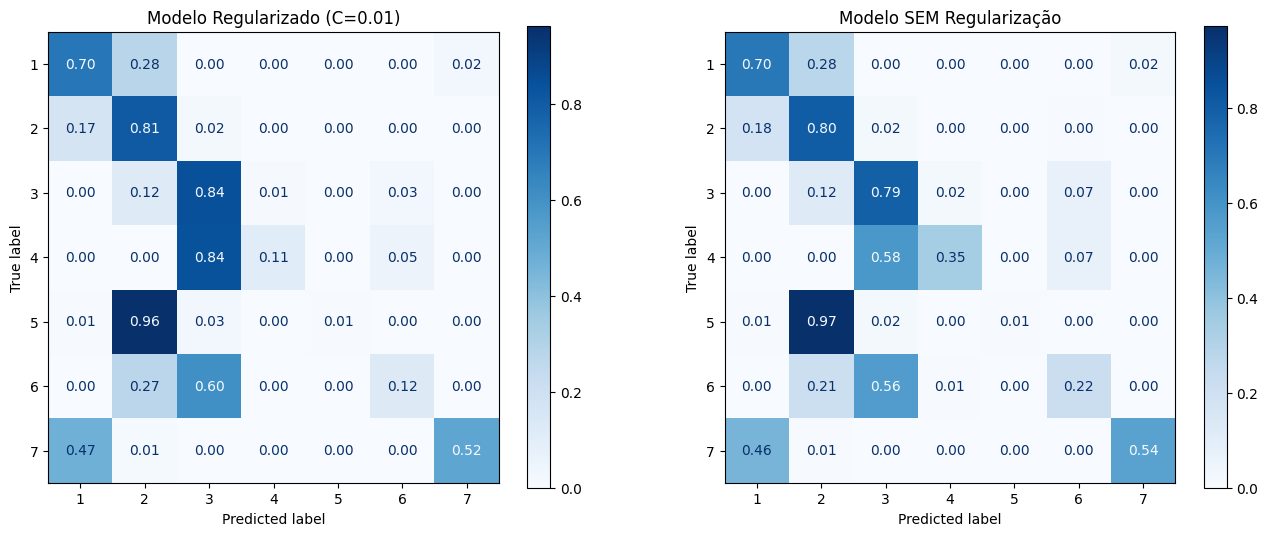

In [55]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

ConfusionMatrixDisplay(cm_reg, display_labels=model_reg.classes_).plot(ax=ax[0], cmap='Blues', values_format='.2f')
ax[0].set_title("Modelo Regularizado (C=0.01)")

ConfusionMatrixDisplay(cm_no_reg, display_labels=model_no_reg.classes_).plot(ax=ax[1], cmap='Blues', values_format='.2f')
ax[1].set_title("Modelo SEM Regularização")

As matrizes normalizadas mostram que as classes majoritárias (1 e 2) são bem classificadas em ambos. A maior confusão ocorre entre classes com características geográficas similares. A regularização impacta as classes minoritárias ao impedir que o modelo as ignore completamente em favor das dominantes, suavizando as fronteiras de decisão.